# Finite-state Markov theory: exact operators before simulation

A small transition matrix is a laboratory in which invariance, reversibility, periodicity,
spectra, Poisson equations, autocorrelation, and finite-sample Monte Carlo error can all be
computed essentially exactly. Simulation is then a validation layer rather than the source of
the theory.

This notebook uses the public `sampler_lab.markov` and `sampler_lab.models` namespaces.

**Output semantics:** exact finite-state operator calculations and exact-invariant simulated
trajectories. Exactness of the invariant law does not imply rapid convergence from an
arbitrary initial state.

Related pages: [finite-state Markov theory](../methods/markov_theory.md),
[public API](../api.md), and [diagnostic conventions](00_orientation_and_diagnostics.ipynb).


In [1]:
import importlib.metadata
import os

import matplotlib.pyplot as plt
import numpy as np

from sampler_lab import spawn_rngs
from sampler_lab.markov import (
    asymptotic_variance,
    autocorrelations,
    finite_sample_mean_variance,
    integrated_autocorrelation_time,
    poisson_martingale_decomposition,
    pushforward_measure,
    simulate_chain,
    solve_poisson_equation,
)
from sampler_lab.models import deterministic_cycle, ring_cosine_observable, ring_random_walk

QUICK_MODE = os.environ.get("SAMPLER_LAB_NOTEBOOK_MODE") == "quick"
SEED = 2022
FIGURE_COUNT = 0


def finish_figure(fig):
    global FIGURE_COUNT
    fig.tight_layout()
    plt.show()
    plt.close(fig)
    FIGURE_COUNT += 1


print("sampler-lab", importlib.metadata.version("sampler-lab"))
print("execution mode:", "quick" if QUICK_MODE else "publication")
print("master seed:", SEED)

sampler-lab 0.12.0
execution mode: publication
master seed: 2022


## 1. Row-stochastic convention and a minimal chain

Sampler Lab uses row-stochastic matrices. Observables are columns and probability measures are
rows:

$$
(Pf)_i=\sum_jP_{ij}f_j,
\qquad
(\mu P)_j=\sum_i\mu_iP_{ij}.
$$

The discrete generator is $L=P-I$. The following lazy nearest-neighbor ring walk is
irreducible, aperiodic, reversible, and uniform at stationarity.


In [2]:
n_states = 12
reversible_chain = ring_random_walk(n_states, clockwise=0.25, counterclockwise=0.25, stay=0.50)
stationary = reversible_chain.invariant_distribution()
observable = ring_cosine_observable(n_states)
spectrum = reversible_chain.spectral_summary(stationary)

print("stationary law:", np.round(stationary, 4))
print("period:", reversible_chain.period)
print("global-balance residual:", reversible_chain.global_balance_residual(stationary))
print("detailed-balance residual:", reversible_chain.detailed_balance_residual(stationary))
print("Poincare gap:", spectrum.poincare_gap)
print("absolute spectral gap:", spectrum.absolute_spectral_gap)

assert np.allclose(stationary, np.full(n_states, 1.0 / n_states))
assert spectrum.reversible

stationary law: [0.0833 0.0833 0.0833 0.0833 0.0833 0.0833 0.0833 0.0833 0.0833 0.0833
 0.0833 0.0833]
period: 1
global-balance residual: 1.3877787807814457e-17
detailed-balance residual: 1.0408340855860843e-17
Poincare gap: 0.0669872981077807
absolute spectral gap: 0.06698729810778092


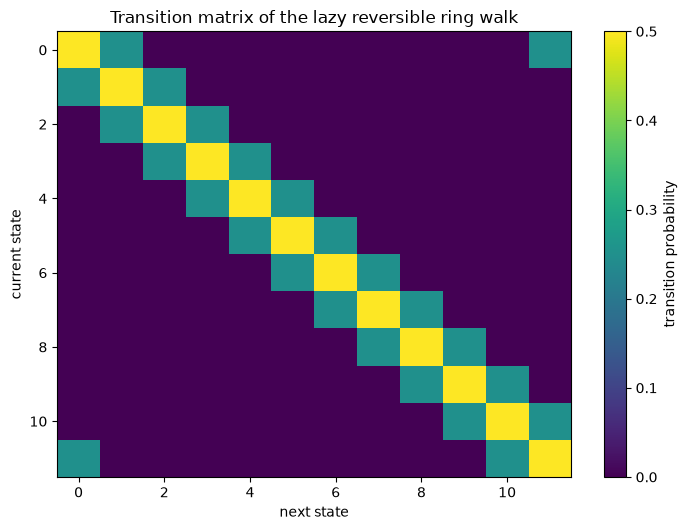

In [3]:
fig, ax = plt.subplots(figsize=(7.2, 5.4))
image = ax.imshow(reversible_chain.transition, aspect="auto")
fig.colorbar(image, ax=ax, label="transition probability")
ax.set_xlabel("next state")
ax.set_ylabel("current state")
ax.set_title("Transition matrix of the lazy reversible ring walk")
finish_figure(fig)

## 2. Invariance is weaker than reversibility, and periodicity is separate

We compare three chains with the same uniform invariant law:

1. a lazy reversible walk;
2. a lazy directed walk, which preserves the same law without detailed balance;
3. a deterministic cycle, which is irreducible but periodic.

Total-variation distance from a point mass should decay for both lazy chains. It does not
decay for the deterministic cycle: its distribution simply rotates forever, even though
selected time averages can have zero asymptotic variance.


In [4]:
chains = {
    "lazy reversible": reversible_chain,
    "lazy directed": ring_random_walk(n_states, clockwise=0.40, counterclockwise=0.10, stay=0.50),
    "deterministic cycle": deterministic_cycle(n_states),
}
initial = np.zeros(n_states)
initial[0] = 1.0
horizon = 70
tv_history = {}

for name, chain in chains.items():
    measure = initial.copy()
    distances = []
    for _ in range(horizon + 1):
        distances.append(0.5 * np.sum(np.abs(measure - stationary)))
        measure = pushforward_measure(measure, chain.transition)
    tv_history[name] = np.asarray(distances)
    print(
        f"{name:>20}: period={chain.period}, "
        f"reversible={chain.spectral_summary(stationary).reversible}, "
        f"final TV={distances[-1]:.4f}"
    )

     lazy reversible: period=1, reversible=True, final TV=0.0049
       lazy directed: period=1, reversible=False, final TV=0.0122
 deterministic cycle: period=12, reversible=False, final TV=0.9167


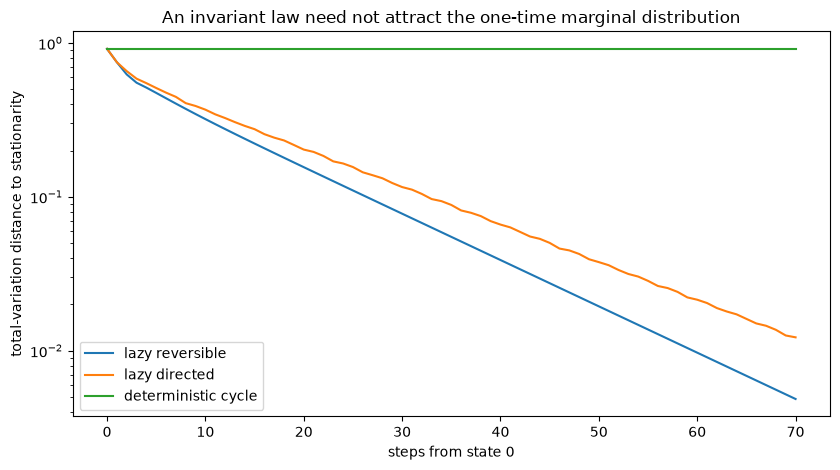

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
for name, distances in tv_history.items():
    ax.plot(np.arange(distances.size), distances, label=name)
ax.set_yscale("log")
ax.set_xlabel("steps from state 0")
ax.set_ylabel("total-variation distance to stationarity")
ax.set_title("An invariant law need not attract the one-time marginal distribution")
ax.legend()
finish_figure(fig)

## 3. Spectral pictures distinguish contraction from rotation

Eigenvalues describe how observables propagate, but several gaps answer different questions.
The absolute gap detects unit-modulus modes; the reversible Poincare gap orders real
nonconstant eigenvalues; the $L^2(\pi)$ singular-value gap applies without reversibility.

The deterministic cycle places every eigenvalue on the unit circle. The directed lazy walk
contracts while rotating, producing complex eigenvalues inside the disk.


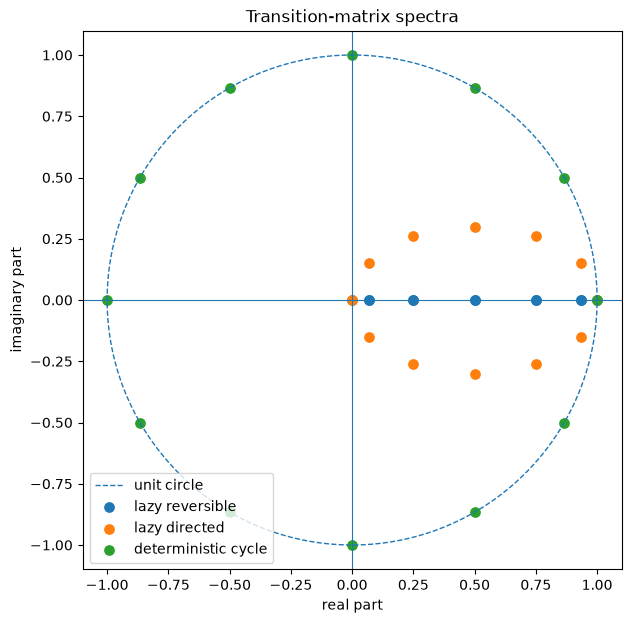

In [6]:
fig, ax = plt.subplots(figsize=(6.4, 6.4))
angle = np.linspace(0.0, 2.0 * np.pi, 400)
ax.plot(np.cos(angle), np.sin(angle), linestyle="--", linewidth=1.0, label="unit circle")
for name, chain in chains.items():
    eigenvalues = np.linalg.eigvals(chain.transition)
    ax.scatter(eigenvalues.real, eigenvalues.imag, s=45, label=name)
ax.axhline(0.0, linewidth=0.8)
ax.axvline(0.0, linewidth=0.8)
ax.set_aspect("equal")
ax.set_xlabel("real part")
ax.set_ylabel("imaginary part")
ax.set_title("Transition-matrix spectra")
ax.legend(loc="lower left")
finish_figure(fig)

## 4. Exact autocorrelation and empirical autocorrelation

Under stationarity,

$$
\rho_k = \frac{\langle g,P^kg\rangle_\pi}{\langle g,g\rangle_\pi},
\qquad g=f-\pi[f].
$$

We can compare this exact sequence to an empirical trajectory. For the directed chain the
cosine observable oscillates as it decorrelates. A short empirical estimate follows the
pattern imperfectly, which is precisely why exact small-state references are valuable.


In [7]:
max_lag = 35
simulated_steps = 8000 if QUICK_MODE else 60000
chain_rngs = spawn_rngs(SEED + 100, len(chains))
exact_acf = {}
empirical_acf = {}


def empirical_autocorrelation(values, max_lag):
    centered = np.asarray(values, dtype=np.float64) - np.mean(values)
    denominator = np.dot(centered, centered)
    return np.array(
        [
            1.0 if lag == 0 else np.dot(centered[:-lag], centered[lag:]) / denominator
            for lag in range(max_lag + 1)
        ]
    )


for (name, chain), rng in zip(chains.items(), chain_rngs, strict=True):
    exact_acf[name] = autocorrelations(chain, observable, max_lag, probabilities=stationary)
    trajectory = simulate_chain(
        chain, rng, n_steps=simulated_steps, initial_distribution=stationary
    )
    empirical_acf[name] = empirical_autocorrelation(
        trajectory.observable_values(observable), max_lag
    )

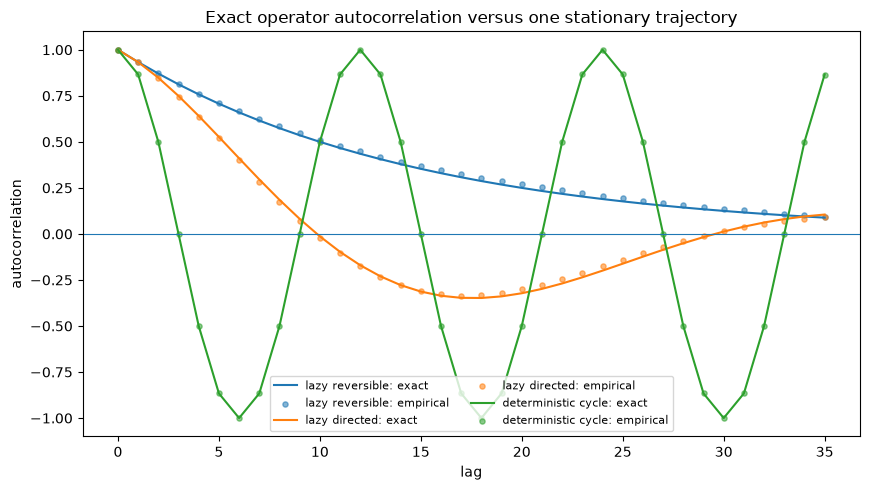

In [8]:
fig, ax = plt.subplots(figsize=(8.8, 5.0))
for name in chains:
    ax.plot(np.arange(max_lag + 1), exact_acf[name], label=f"{name}: exact")
    ax.scatter(
        np.arange(max_lag + 1),
        empirical_acf[name],
        s=14,
        alpha=0.55,
        label=f"{name}: empirical",
    )
ax.axhline(0.0, linewidth=0.8)
ax.set_xlabel("lag")
ax.set_ylabel("autocorrelation")
ax.set_title("Exact operator autocorrelation versus one stationary trajectory")
ax.legend(ncol=2, fontsize=8)
finish_figure(fig)

## 5. Poisson equations predict Monte Carlo error

For centered $g=f-\pi[f]$, Sampler Lab solves

$$
(P-I)u=g, \qquad \pi[u]=0.
$$

The solution yields the exact asymptotic variance and an algebraic martingale decomposition.
It also gives a finite-$N$ variance formula from exact autocovariances. We compare that
formula with repeated stationary simulations over a grid of sample sizes.


In [9]:
poisson = solve_poisson_equation(reversible_chain, observable, probabilities=stationary)
iat = integrated_autocorrelation_time(reversible_chain, observable, probabilities=stationary)
asymptotic = asymptotic_variance(reversible_chain, observable, probabilities=stationary)
test_path = simulate_chain(
    reversible_chain,
    np.random.default_rng(SEED + 101),
    n_steps=100,
    initial_distribution=stationary,
)
decomposition = poisson_martingale_decomposition(
    reversible_chain, observable, test_path.states, probabilities=stationary
)

print("Poisson residual:", poisson.residual_norm)
print("centering residual:", poisson.centering_residual)
print("exact IAT:", round(iat, 5))
print("asymptotic variance:", round(asymptotic, 5))
print("martingale identity residual:", decomposition.residual)

assert poisson.residual_norm < 1e-10
assert abs(decomposition.residual) < 1e-9

Poisson residual: 1.4432899320127035e-15
centering residual: 6.661338147750939e-16
exact IAT: 28.85641
asymptotic variance: 14.4282
martingale identity residual: -3.552713678800501e-15


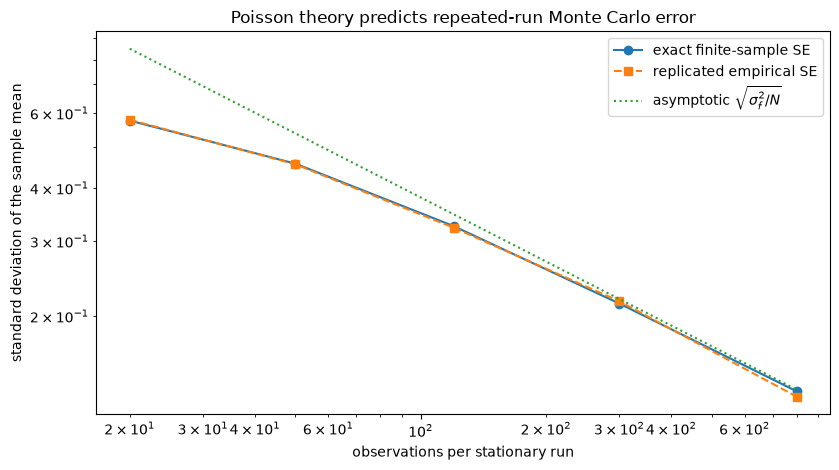

largest empirical/exact SE relative gap: 0.0285


In [10]:
sample_sizes = np.array([20, 50, 120] if QUICK_MODE else [20, 50, 120, 300, 800])
replicates = 500 if QUICK_MODE else 3500
replicate_rngs = spawn_rngs(SEED + 110, sample_sizes.size)
exact_standard_errors = []
empirical_standard_errors = []

for sample_size, rng in zip(sample_sizes, replicate_rngs, strict=True):
    exact_variance = finite_sample_mean_variance(
        reversible_chain,
        observable,
        int(sample_size),
        probabilities=stationary,
    )
    exact_standard_errors.append(np.sqrt(exact_variance))

    states = rng.choice(n_states, size=replicates, p=stationary)
    totals = observable[states].copy()
    cumulative = np.cumsum(reversible_chain.transition, axis=1)
    for _ in range(1, int(sample_size)):
        draws = rng.random(replicates)
        states = np.sum(draws[:, None] > cumulative[states], axis=1)
        states = np.minimum(states, n_states - 1)
        totals += observable[states]
    empirical_standard_errors.append(np.std(totals / sample_size, ddof=1))

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.loglog(sample_sizes, exact_standard_errors, "o-", label="exact finite-sample SE")
ax.loglog(sample_sizes, empirical_standard_errors, "s--", label="replicated empirical SE")
ax.loglog(
    sample_sizes,
    np.sqrt(asymptotic / sample_sizes),
    linestyle=":",
    label=r"asymptotic $\sqrt{\sigma_f^2/N}$",
)
ax.set_xlabel("observations per stationary run")
ax.set_ylabel("standard deviation of the sample mean")
ax.set_title("Poisson theory predicts repeated-run Monte Carlo error")
ax.legend()
finish_figure(fig)

relative_gap = np.max(
    np.abs(np.asarray(empirical_standard_errors) - np.asarray(exact_standard_errors))
    / np.asarray(exact_standard_errors)
)
print("largest empirical/exact SE relative gap:", round(float(relative_gap), 4))

## Controlled failure: a periodic chain can average well without mixing

The deterministic cycle never approaches stationarity in total variation from a point mass,
but the cosine observable sums to zero over a complete cycle. Its Poisson asymptotic variance
is therefore zero. This is not a contradiction: distributional convergence and the variance
of one chosen time average are different properties.

This example is a warning against reducing Markov-chain quality to a single spectral number,
a single observable, or a single attractive trajectory.


In [11]:
periodic = chains["deterministic cycle"]
periodic_iat = integrated_autocorrelation_time(periodic, observable, probabilities=stationary)
periodic_asymptotic = asymptotic_variance(periodic, observable, probabilities=stationary)
print("deterministic-cycle IAT:", periodic_iat)
print("deterministic-cycle asymptotic variance:", periodic_asymptotic)
print("deterministic-cycle TV distance after 70 steps:", tv_history["deterministic cycle"][-1])

assert periodic_asymptotic < 1e-10
assert tv_history["deterministic cycle"][-1] > 0.8
assert relative_gap < (0.22 if QUICK_MODE else 0.10)
assert FIGURE_COUNT >= 5
print(f"completed finite-state Markov notebook with {FIGURE_COUNT} figures")

deterministic-cycle IAT: 0.0
deterministic-cycle asymptotic variance: 0.0
deterministic-cycle TV distance after 70 steps: 0.9166666666666667
completed finite-state Markov notebook with 5 figures
